In [1]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from matplotlib import gridspec

### Helper functions

In [2]:

def read_graph(graph_file_path):

    edges = []
    with open(graph_file_path, 'r') as file:
        N, E = map(int, file.readline().split())
        #print(N)
        for line in file:
            v1, v2, w = map(float, line.split())
            edges.append((int(v1) - 1, int(v2) - 1, w))
    return N, edges

def read_graph_to_qubo(graph_file_path):

    with open(graph_file_path, 'r') as file:
        N, E = map(int, file.readline().split())
        qubo = np.zeros((N,N))
        for line in file:
            v1, v2, w = map(float, line.split())
            if(v1 < v2):
                qubo[int(v1) - 1, int(v2) - 1] = w
            else:
                qubo[int(v2) - 1, int(v1) - 1] = w

    return N, qubo



### Reading in data from files

In [3]:
mabs = ["0.01", "0.001", "0.0001", "1.0e-5"]#, "1.0e-6"]
Ws = [3,4]#,3,4,5,6,7,8]

graph_datafile = f"../data/PP_p1_tests_ieva/true_energies.json"
graph_dir = f"../data/PP_p1_tests_ieva/graphs/"

with open(graph_datafile) as f:
    graph_data = json.load(f)

graph_ids = list(graph_data.keys())

data = {}
counter = 0
for k,v in graph_data.items():
    N, edges = read_graph(os.path.join(graph_dir, f"{k}.txt"))
    num_edges = len(edges)
    density = 2*num_edges/(N *(N - 1))
    true_energy = v
    for W in Ws:
        for mab in mabs:  
            pp_file = f"../data/PP_p1_tests_ieva/results/W{W}-mab{mab}-p1.json"
            with open(pp_file) as f:
                pp_data = json.load(f)
            if(k in list(pp_data.keys())):
                pp_energy = pp_data[k]["energy"]
                pp_time = pp_data[k]["time"]
                #print(W, mab, true_energy, pp_energy, pp_time)
                
                data[counter] = {"graph_id": k,"N": N, "W": W, "mab": mab, "pp_energy": pp_energy, "pp_time": pp_time, "true_energy": true_energy, "density": density}
                counter += 1

### Plotting figure from paper

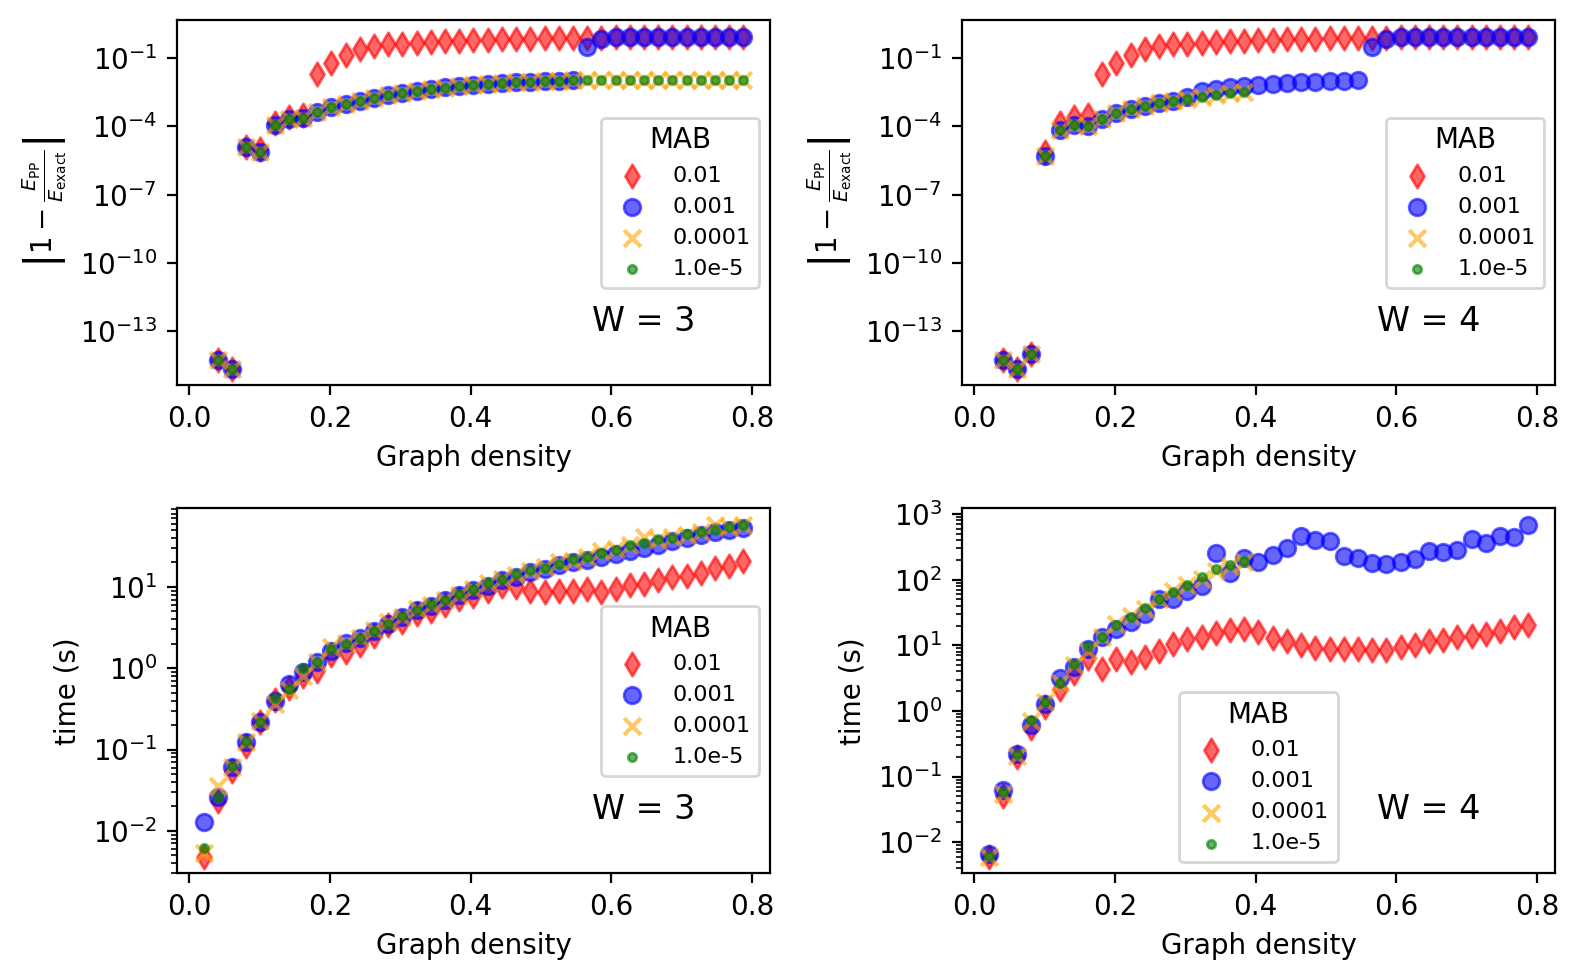

In [4]:
def plot_data(ax, data, W, energy = True, title = ""):

    colors = ['r', 'b', 'orange', 'g']
    markers = ['d', 'o', 'x', '.']

    count = 0
    for mab in mabs:
        densities = []
        ars = []
        for k,v in data.items():
            if(v["W"] == W):
                m = v["mab"]
                if(m == mab): 
                    densities.append(v["density"])
                    if(energy): ars.append(abs(1 - v["pp_energy"]/v["true_energy"]))
                    else: ars.append(v["pp_time"]) #(abs(1 - v["pp_energy"]/v["true_energy"]))#(v["pp_time"])
        ax.scatter(densities, ars, label = f"{mab}", marker= markers[count], c = colors[count],alpha = 0.6)
        count += 1

    ax.set_xlabel("Graph density")
    if(energy): ax.set_ylabel(r'$\left|1 - \frac{E_{\rm PP}}{E_{\rm exact}} \right|$')
    else: ax.set_ylabel("time (s)")
    ax.legend(title="MAB", fontsize = 8)
    ax.set_yscale('log')
    ax.text(0.7, 0.15, f'W = {W}', transform=ax.transAxes, fontsize = 12)

    ax.set_title(title)

fig = plt.figure(dpi = 200, figsize=(8,5))
gspec = gridspec.GridSpec(2, 2)

ax0 = fig.add_subplot(gspec[0, 0])
ax1 = fig.add_subplot(gspec[0, 1])
ax2 = fig.add_subplot(gspec[1, 0])
ax3 = fig.add_subplot(gspec[1, 1])

plot_data(ax0, data, W = 3)
plot_data(ax1, data, W = 4)
plot_data(ax2, data, W = 3, energy = False)
plot_data(ax3, data, W = 4, energy = False)

plt.tight_layout()
#plt.grid(alpha = 0.3)

plt.savefig(f"figures/figure4.pdf")